# 第7节：对抗防御方法与鲁棒性提升

本节目标：

1. 系统了解四类常用防御思路：
   - 对抗训练（Adversarial Training）
   - 输入变换（Input Transformation）
   - 梯度掩蔽（Gradient Masking / Obfuscated Gradients）
   - 随机平滑（Randomized Smoothing）
2. 认识“表面鲁棒”与“真实鲁棒”的差异：
   - 错误的防御可能只是让梯度变得不可用，而不是真正提升鲁棒性
3. 掌握鲁棒性评估指标与实验设计：
   - Clean Acc vs Robust Acc
   - Attack Success Rate / Robust Error
   - 不同 ε 下的鲁棒曲线
   - 强攻击（PGD）与评估规范（EOT / BPDA 的思想启蒙）


## 0. 路径与环境约定

统一使用：

```python
PROJECT_ROOT = Path.cwd().resolve().parent
DATA_DIR = PROJECT_ROOT / 'data'
```

输入统一归一化到 `[0,1]`，便于定义 L∞ 扰动 ε。

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

PROJECT_ROOT = Path.cwd().resolve().parent
DATA_DIR = PROJECT_ROOT / "data"

print('CWD:', Path.cwd())
print('PROJECT_ROOT:', PROJECT_ROOT)
print('DATA_DIR exists:', DATA_DIR.exists(), '|', DATA_DIR)
print('torch:', torch.__version__, 'cuda available:', torch.cuda.is_available())

device = torch.device('cpu')


CWD: C:\Users\wingl\PycharmProjects\adversarialmeow\notebooks
PROJECT_ROOT: C:\Users\wingl\PycharmProjects\adversarialmeow
DATA_DIR exists: True | C:\Users\wingl\PycharmProjects\adversarialmeow\data
torch: 2.10.0+cpu cuda available: False


## 1. 数据加载与划分

支持：
- `data/digits.npz`（X, y）
- `data/X.npy` + `data/y.npy`
- 回退：sklearn digits


In [2]:
def load_course_data():
    npz_path = DATA_DIR / 'digits.npz'
    if npz_path.exists():
        arr = np.load(npz_path)
        X = arr['X'].astype(np.float32)
        y = arr['y'].astype(np.int64)
        return X, y, f'Loaded local NPZ: {npz_path}'

    x_npy = DATA_DIR / 'X.npy'
    y_npy = DATA_DIR / 'y.npy'
    if x_npy.exists() and y_npy.exists():
        X = np.load(x_npy).astype(np.float32)
        y = np.load(y_npy).astype(np.int64)
        return X, y, f'Loaded local NPY: {x_npy.name}, {y_npy.name}'

    from sklearn.datasets import load_digits
    ds = load_digits()
    X = ds.data.astype(np.float32)
    y = ds.target.astype(np.int64)
    return X, y, 'Loaded sklearn digits fallback'

X, y, info = load_course_data()
print(info)

x_min, x_max = float(X.min()), float(X.max())
if x_max > 1.0:
    X01 = (X - x_min) / (x_max - x_min + 1e-12)
else:
    X01 = np.clip(X, 0.0, 1.0)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X01, y, test_size=0.25, random_state=42, stratify=y
)

X_train_t = torch.tensor(X_train, dtype=torch.float32, device=device)
y_train_t = torch.tensor(y_train, dtype=torch.long, device=device)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32, device=device)
y_test_t  = torch.tensor(y_test,  dtype=torch.long, device=device)

print('train:', X_train_t.shape, y_train_t.shape)
print('test :', X_test_t.shape, y_test_t.shape)


Loaded local NPZ: C:\Users\wingl\PycharmProjects\adversarialmeow\data\digits.npz
train: torch.Size([1347, 64]) torch.Size([1347])
test : torch.Size([450, 64]) torch.Size([450])


## 2. 基线模型

用一个轻量 MLP 作为教学基线（CPU 可跑）。

In [4]:
class MLP(nn.Module):
    def __init__(self, in_dim=64, hidden=128, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, num_classes)
        )
    def forward(self, x):
        return self.net(x)

def accuracy(model, X, y, batch=256):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for i in range(0, len(X), batch):
            xb = X[i:i+batch]
            yb = y[i:i+batch]
            pred = model(xb).argmax(dim=1)
            correct += int((pred == yb).sum().item())
            total += int(len(xb))
    return correct / max(total, 1)

def train_standard(model, X, y, epochs=12, batch=256, lr=1e-3):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    for ep in range(1, epochs+1):
        model.train()
        perm = torch.randperm(len(X), device=X.device)
        for i in range(0, len(X), batch):
            idx = perm[i:i+batch]
            xb, yb = X[idx], y[idx]
            loss = F.cross_entropy(model(xb), yb)
            opt.zero_grad(); loss.backward(); opt.step()
        if ep == 1 or ep == epochs or ep % 2 == 0:
            print(f'Epoch {ep:02d} | train acc={accuracy(model, X, y):.4f} | test acc={accuracy(model, X_test_t, y_test_t):.4f}')

baseline = MLP().to(device)
train_standard(baseline, X_train_t, y_train_t, epochs=20)
print('Baseline clean test acc:', accuracy(baseline, X_test_t, y_test_t))


Epoch 01 | train acc=0.3712 | test acc=0.3689
Epoch 02 | train acc=0.7246 | test acc=0.7111
Epoch 04 | train acc=0.8122 | test acc=0.7800
Epoch 06 | train acc=0.8389 | test acc=0.8044
Epoch 08 | train acc=0.8805 | test acc=0.8400
Epoch 10 | train acc=0.9094 | test acc=0.8689
Epoch 12 | train acc=0.9243 | test acc=0.9044
Epoch 14 | train acc=0.9391 | test acc=0.9200
Epoch 16 | train acc=0.9473 | test acc=0.9333
Epoch 18 | train acc=0.9569 | test acc=0.9467
Epoch 20 | train acc=0.9584 | test acc=0.9489
Baseline clean test acc: 0.9488888888888889


## 3. 强攻击作为评估工具：PGD（白盒）

评估鲁棒性不能只用弱攻击。
在教学中，PGD 常作为“强一阶基线”。

In [5]:
def pgd_attack(model, x, y, eps=0.1, alpha=0.02, steps=20, random_start=True):
    model.eval()
    x0 = x.detach()
    x_adv = x0.clone()
    if random_start:
        x_adv = x_adv + torch.empty_like(x_adv).uniform_(-eps, eps)
        x_adv = torch.clamp(x_adv, 0.0, 1.0)
    for _ in range(steps):
        x_adv.requires_grad_(True)
        loss = F.cross_entropy(model(x_adv), y)
        grad = torch.autograd.grad(loss, x_adv)[0]
        x_adv = x_adv + alpha * torch.sign(grad)
        x_adv = torch.max(torch.min(x_adv, x0 + eps), x0 - eps)
        x_adv = torch.clamp(x_adv.detach(), 0.0, 1.0)
    return x_adv

def eval_robust_acc(model, X, y, eps=0.1, alpha=0.02, steps=20, batch=256):
    model.eval()
    correct = 0
    total = 0
    for i in range(0, len(X), batch):
        xb = X[i:i+batch]
        yb = y[i:i+batch]
        x_adv = pgd_attack(model, xb, yb, eps=eps, alpha=alpha, steps=steps, random_start=True)
        with torch.no_grad():
            pred = model(x_adv).argmax(dim=1)
        correct += int((pred == yb).sum().item())
        total += int(len(xb))
    return correct / max(total, 1)

eps = 0.10
print('Baseline clean acc :', accuracy(baseline, X_test_t, y_test_t))
print('Baseline robust acc:', eval_robust_acc(baseline, X_test_t, y_test_t, eps=eps, alpha=0.02, steps=20))


Baseline clean acc : 0.9488888888888889
Baseline robust acc: 0.52


## 4. 防御一：对抗训练（Adversarial Training）

核心思想：训练时把“生成对抗样本”纳入训练环节：
- 每个 batch 先用当前模型生成 x_adv（例如 PGD-1 或 PGD-k）
- 用 (x_adv, y) 反向传播更新模型

对抗训练常被视作最可靠的鲁棒性提升方法之一。
但代价是：训练更慢、对攻击强度/ε敏感。

In [6]:
def train_adversarial(model, X, y, eps=0.10, alpha=0.02, pgd_steps=5,
                      epochs=12, batch=256, lr=1e-3):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    for ep in range(1, epochs+1):
        model.train()
        perm = torch.randperm(len(X), device=X.device)
        for i in range(0, len(X), batch):
            idx = perm[i:i+batch]
            xb, yb = X[idx], y[idx]

            # 生成训练用对抗样本（PGD-k）
            x_adv = pgd_attack(model, xb, yb, eps=eps, alpha=alpha, steps=pgd_steps, random_start=True)

            logits = model(x_adv)
            loss = F.cross_entropy(logits, yb)
            opt.zero_grad(); loss.backward(); opt.step()

        if ep == 1 or ep == epochs or ep % 2 == 0:
            ca = accuracy(model, X_test_t, y_test_t)
            ra = eval_robust_acc(model, X_test_t, y_test_t, eps=eps, alpha=alpha, steps=20)
            print(f'[AdvTrain] Epoch {ep:02d} | clean={ca:.4f} | robust(PGD20)={ra:.4f}')

advtrained = MLP().to(device)
train_adversarial(advtrained, X_train_t, y_train_t, eps=0.10, alpha=0.02, pgd_steps=5, epochs=12)

print('AdvTrained clean acc :', accuracy(advtrained, X_test_t, y_test_t))
print('AdvTrained robust acc:', eval_robust_acc(advtrained, X_test_t, y_test_t, eps=0.10, alpha=0.02, steps=20))


[AdvTrain] Epoch 01 | clean=0.4356 | robust(PGD20)=0.1778
[AdvTrain] Epoch 02 | clean=0.7622 | robust(PGD20)=0.3578
[AdvTrain] Epoch 04 | clean=0.7489 | robust(PGD20)=0.5533
[AdvTrain] Epoch 06 | clean=0.7578 | robust(PGD20)=0.5667
[AdvTrain] Epoch 08 | clean=0.7822 | robust(PGD20)=0.6000
[AdvTrain] Epoch 10 | clean=0.8311 | robust(PGD20)=0.6089
[AdvTrain] Epoch 12 | clean=0.8622 | robust(PGD20)=0.6289
AdvTrained clean acc : 0.8622222222222222
AdvTrained robust acc: 0.6266666666666667


## 5. 防御二：输入变换（Input Transformation）

输入变换常见做法：
- 平滑 / 去噪（例如均值滤波、简单模糊）
- 量化 / 压缩（降低精度）

直觉：试图削弱细小高频扰动。
风险：
- 可能降低 clean 精度
- 可能引入“梯度不可用”的假象（需要更强评估手段，如 EOT）

In [75]:
def smooth_transform(x, kernel_size=1, alpha=0.2):
    """
    x: (B, 64) 输入数据
    alpha: 平滑图的占比。0.2 表示 0.8*原图 + 0.2*平滑图
    """
    B = x.shape[0]
    # 1. 保留原图
    origin = x.view(B, 1, 8, 8)
    
    # 2. 生成 3x3 平滑图
    pad = kernel_size // 2
    img_pad = F.pad(origin, (pad, pad, pad, pad), mode='reflect')
    smoothed = F.avg_pool2d(img_pad, kernel_size=kernel_size, stride=1)
    
    # 3. 混合：0.8 * 原图 + 0.2 * 平滑图
    # 这样既不会改变图像尺寸(始终是8x8)，也不会丢失太多特征
    out = (1 - alpha) * origin + alpha * smoothed
    
    return out.view(B, 64)

def quantize_transform(x, levels=16):
    """简单量化到离散 levels。"""
    return torch.round(x * (levels - 1)) / (levels - 1)

class DefendedModel(nn.Module):
    def __init__(self, base_model, transform_fn):
        super().__init__()
        self.base = base_model
        self.transform_fn = transform_fn
    def forward(self, x):
        x_t = self.transform_fn(x)
        return self.base(x_t)

# 防御包装：对 baseline 做输入平滑与量化
def_smooth = DefendedModel(baseline, lambda x: smooth_transform(x, kernel_size=5,alpha=0.02)).to(device)
def_quant  = DefendedModel(baseline, lambda x: quantize_transform(x, levels=16)).to(device)

eps = 0.10
print('--- Baseline ---')
print('clean :', accuracy(baseline, X_test_t, y_test_t))
print('robust:', eval_robust_acc(baseline, X_test_t, y_test_t, eps=eps, alpha=0.02, steps=20))

print('--- Smooth Defense (wrap baseline) ---')
print('clean :', accuracy(def_smooth, X_test_t, y_test_t))
print('robust:', eval_robust_acc(def_smooth, X_test_t, y_test_t, eps=eps, alpha=0.02, steps=20))

print('--- Quant Defense (wrap baseline) ---')
print('clean :', accuracy(def_quant, X_test_t, y_test_t))
print('robust:', eval_robust_acc(def_quant, X_test_t, y_test_t, eps=eps, alpha=0.02, steps=20))


--- Baseline ---
clean : 0.9488888888888889
robust: 0.5155555555555555
--- Smooth Defense (wrap baseline) ---
clean : 0.9511111111111111
robust: 0.5177777777777778
--- Quant Defense (wrap baseline) ---
clean : 0.9466666666666667
robust: 0.9444444444444444


## 6. 防御三：梯度掩蔽（Gradient Masking）现象演示

梯度掩蔽/混淆（obfuscated gradients）不是一种真正可靠的防御，
但在课堂里很适合用来说明“为什么评估很关键”。

常见表现：
- 用一阶白盒攻击（FGSM/PGD）打不动，看似鲁棒
- 但换成更合适的评估（EOT / BPDA / 迁移 / 黑盒查询）后崩溃

这里我们构造一个**不可导的离散化**，它会让梯度变得不可靠，从而让朴素 PGD 失效。
注意：这不是“好防御”，只是教学用现象复现。


In [76]:
def hard_round_transform(x, levels=8):
    # 非平滑、离散、对梯度不友好
    return torch.round(x * (levels - 1)) / (levels - 1)

def_hard = DefendedModel(baseline, lambda x: hard_round_transform(x, levels=8)).to(device)

eps = 0.10
print('Hard-round defense:')
print('clean :', accuracy(def_hard, X_test_t, y_test_t))
print('robust(PGD20 naive):', eval_robust_acc(def_hard, X_test_t, y_test_t, eps=eps, alpha=0.02, steps=20))

print('\n说明：如果这里 robust 看起来提升很大，不能直接下结论。')
print('需要更强的评估方法（EOT / BPDA 等），下一格给出 EOT 启蒙实现。')


Hard-round defense:
clean : 0.9444444444444444
robust(PGD20 naive): 0.94

说明：如果这里 robust 看起来提升很大，不能直接下结论。
需要更强的评估方法（EOT / BPDA 等），下一格给出 EOT 启蒙实现。


### 6.1 EOT 启蒙：对随机/不可导变换的“期望梯度”攻击

EOT（Expectation over Transformation）思想：
- 变换（尤其随机变换）会导致单次梯度不稳定
- 通过多次采样取平均梯度，提高攻击稳定性

下面给出一个简化版：
- 在每一步 PGD 中，计算 K 次前向/反向并对梯度求平均

注意：这仍是教学启蒙版，不是完整 BPDA/EOT 框架。

In [77]:
def pgd_eot_attack(model, x, y, eps=0.1, alpha=0.02, steps=20, eot_samples=8):
    model.eval()
    x0 = x.detach()
    x_adv = x0.clone() + torch.empty_like(x0).uniform_(-eps, eps)
    x_adv = torch.clamp(x_adv, 0.0, 1.0)

    for _ in range(steps):
        x_adv.requires_grad_(True)
        grads = []
        for _k in range(eot_samples):
            logits = model(x_adv)
            loss = F.cross_entropy(logits, y)
            grad = torch.autograd.grad(loss, x_adv, retain_graph=True)[0]
            grads.append(grad)
        grad_mean = torch.stack(grads, dim=0).mean(dim=0)

        x_adv = x_adv + alpha * torch.sign(grad_mean)
        x_adv = torch.max(torch.min(x_adv, x0 + eps), x0 - eps)
        x_adv = torch.clamp(x_adv.detach(), 0.0, 1.0)

    return x_adv

def eval_robust_acc_eot(model, X, y, eps=0.1, alpha=0.02, steps=20, eot_samples=8, batch=128):
    model.eval()
    correct, total = 0, 0
    for i in range(0, len(X), batch):
        xb, yb = X[i:i+batch], y[i:i+batch]
        x_adv = pgd_eot_attack(model, xb, yb, eps=eps, alpha=alpha, steps=steps, eot_samples=eot_samples)
        with torch.no_grad():
            pred = model(x_adv).argmax(dim=1)
        correct += int((pred == yb).sum().item())
        total += int(len(xb))
    return correct / max(total, 1)

eps = 0.10
print('Hard-round defense:')
print('robust(PGD20 naive):', eval_robust_acc(def_hard, X_test_t, y_test_t, eps=eps, alpha=0.02, steps=20))
print('robust(PGD20 + EOT):', eval_robust_acc_eot(def_hard, X_test_t, y_test_t, eps=eps, alpha=0.02, steps=20, eot_samples=8))


Hard-round defense:
robust(PGD20 naive): 0.9333333333333333
robust(PGD20 + EOT): 0.9488888888888889


## 7. 防御四：随机平滑（Randomized Smoothing）

随机平滑是一类“可认证”防御思路：
- 对输入加噪声（常用高斯噪声），对模型输出进行投票/平均
- 平滑后的分类器对一定 L2 半径内扰动可给出概率意义上的鲁棒保证（理论层面）

本节做教学实现：
- 给定输入 x，采样多次：x+N(0,σ^2)
- 多次预测取多数票，得到平滑预测

注意：digits 这里是 flat 向量，仍可用。

In [78]:
def smooth_predict(model, x, sigma=0.10, samples=64):
    """对单个 batch 做随机平滑预测：多数票。"""
    model.eval()
    B, D = x.shape
    votes = []
    with torch.no_grad():
        for _ in range(samples):
            noise = torch.randn_like(x) * sigma
            xn = torch.clamp(x + noise, 0.0, 1.0)
            pred = model(xn).argmax(dim=1)
            votes.append(pred)
    votes = torch.stack(votes, dim=0)  # (S, B)
    # 多数票
    preds = []
    for i in range(B):
        binc = torch.bincount(votes[:, i], minlength=10)
        preds.append(int(torch.argmax(binc).item()))
    return torch.tensor(preds, device=x.device)

def smooth_accuracy(model, X, y, sigma=0.10, samples=64, batch=128):
    correct, total = 0, 0
    for i in range(0, len(X), batch):
        xb, yb = X[i:i+batch], y[i:i+batch]
        pred = smooth_predict(model, xb, sigma=sigma, samples=samples)
        correct += int((pred == yb).sum().item())
        total += int(len(xb))
    return correct / max(total, 1)

sigma = 0.10
print('Baseline clean acc           :', accuracy(baseline, X_test_t, y_test_t))
print('Baseline smoothed clean acc  :', smooth_accuracy(baseline, X_test_t, y_test_t, sigma=sigma, samples=64))

# 在对抗样本上评估平滑预测（这里用 PGD 对 baseline 生成 adv）
eps = 0.10
X_adv = pgd_attack(baseline, X_test_t[:400], y_test_t[:400], eps=eps, alpha=0.02, steps=20, random_start=True)
print('Smoothed acc on PGD adv (subset):', smooth_accuracy(baseline, X_adv, y_test_t[:400], sigma=sigma, samples=64))


Baseline clean acc           : 0.9488888888888889
Baseline smoothed clean acc  : 0.9444444444444444
Smoothed acc on PGD adv (subset): 0.5675


## 8. 鲁棒性评估指标介绍与实验设计

### 8.1 指标
- Clean Accuracy：干净样本准确率
- Robust Accuracy：在指定攻击/ε下的准确率（越高越好）
- Attack Success Rate：攻击成功率（untargeted：pred != y，越低越好）
- Robust Curve：ε 从小到大扫描得到的鲁棒曲线

### 8.2 设计要点（课堂强调）
- 必须用“足够强”的攻击评估（PGD 是基本盘）
- 防御若包含随机/不可导变换，应考虑 EOT / BPDA 思想
- 报告必须同时给出 clean 与 robust（不能只报一个）

下面我们统一对比：
- baseline
- advtrained
- smooth-wrap baseline
- quant-wrap baseline
- hard-round（用于展示梯度掩蔽风险）

用 PGD20 扫描 ε，画鲁棒曲线。


==== baseline ====
eps=0.000 robust_acc=0.9489
eps=0.020 robust_acc=0.8933
eps=0.050 robust_acc=0.8133
eps=0.080 robust_acc=0.6356
eps=0.100 robust_acc=0.5200
eps=0.120 robust_acc=0.3733
eps=0.150 robust_acc=0.1978
eps=0.200 robust_acc=0.0422

==== advtrained ====
eps=0.000 robust_acc=0.8622
eps=0.020 robust_acc=0.8356
eps=0.050 robust_acc=0.7644
eps=0.080 robust_acc=0.6911
eps=0.100 robust_acc=0.6244
eps=0.120 robust_acc=0.5622
eps=0.150 robust_acc=0.4467
eps=0.200 robust_acc=0.2133

==== smooth_wrap ====
eps=0.000 robust_acc=0.9511
eps=0.020 robust_acc=0.8911
eps=0.050 robust_acc=0.8111
eps=0.080 robust_acc=0.6311
eps=0.100 robust_acc=0.5089
eps=0.120 robust_acc=0.3711
eps=0.150 robust_acc=0.1844
eps=0.200 robust_acc=0.0422

==== quant_wrap ====
eps=0.000 robust_acc=0.9467
eps=0.020 robust_acc=0.9467
eps=0.050 robust_acc=0.9467
eps=0.080 robust_acc=0.9400
eps=0.100 robust_acc=0.9444
eps=0.120 robust_acc=0.9400
eps=0.150 robust_acc=0.9333
eps=0.200 robust_acc=0.9444

==== hard_round 

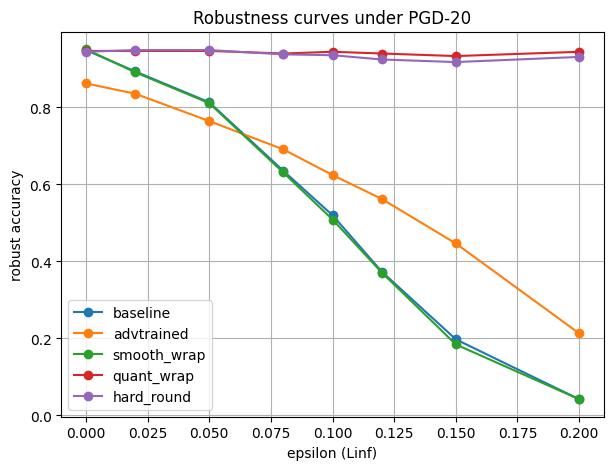

In [79]:
def robust_curve(model, X, y, eps_list, alpha=0.02, steps=20):
    r = []
    for eps in eps_list:
        ra = eval_robust_acc(model, X, y, eps=eps, alpha=alpha, steps=steps)
        r.append(ra)
        print(f'eps={eps:.3f} robust_acc={ra:.4f}')
    return r

eps_list = [0.00, 0.02, 0.05, 0.08, 0.10, 0.12, 0.15, 0.20]

models = {
    'baseline': baseline,
    'advtrained': advtrained,
    'smooth_wrap': def_smooth,
    'quant_wrap': def_quant,
    'hard_round': def_hard,
}

curves = {}
for name, m in models.items():
    print('\n====', name, '====')
    curves[name] = robust_curve(m, X_test_t, y_test_t, eps_list, alpha=0.02, steps=20)

plt.figure(figsize=(7,5))
for name in models.keys():
    plt.plot(eps_list, curves[name], marker='o', label=name)
plt.title('Robustness curves under PGD-20')
plt.xlabel('epsilon (Linf)')
plt.ylabel('robust accuracy')
plt.grid(True)
plt.legend()
plt.show()


## 9. 本节小结

1) 对抗训练：通常能带来更“真实”的鲁棒性提升，但训练成本更高。

2) 输入变换：可能有帮助，但容易造成评估偏差；随机/不可导变换要警惕。

3) 梯度掩蔽：让白盒梯度攻击失效并不等于鲁棒；需要更强评估（EOT/BPDA/迁移/查询）。

4) 随机平滑：通过噪声投票构建平滑分类器，可作为认证鲁棒思路的入门。

5) 鲁棒性评估：必须同时报告 clean 与 robust，并用强攻击扫描 ε 形成鲁棒曲线。

## 10. 本节练习

1) 将对抗训练的 pgd_steps 从 1/3/5/10 改动，比较：
- clean acc
- robust acc（PGD20）

2) 输入变换（平滑/量化）的参数搜索：
- kernel_size / levels
观察其对 clean 与 robust 的权衡。

3) 梯度掩蔽现象：
- 对 hard_round，比较 naive PGD 与 PGD+EOT 的鲁棒性评估结果。

4) 随机平滑：
- 改 sigma 与 samples，观察平滑预测的稳定性与代价。
